# Feature Scaling
This trimmed notebook contains only the Feature Scaling section. Each code cell below includes detailed comments and step-by-step breakdowns for complex lines.

****Summary****

Here is your quick-reference cheat sheet for feature scaling and transformation. It is structured perfectly for a last-minute interview recap to help you explain **what** each scaler does, **why** you would choose it, and **when** to deploy it.

### 🚀 Feature Scaling & Transformation Matrix

| Scaler / Transform | Core Mechanism | Why Use It? (The Benefit) | When to Use (Best Scenarios) | When to Avoid ❌ |
| --- | --- | --- | --- | --- |
| **Standard Scaler** | Shifts mean to $0$ and scales variance to $1$. | Preserves the distribution shape while putting features on the same scale. | Data is already **normally distributed** (Gaussian) with **no extreme outliers**. | Your data contains **heavy outliers** (they will distort the mean and squish normal data). |
| **Robust Scaler** | Scales data using the **Median** and **IQR** ($Q_3 - Q_1$). | Scales features cleanly **without being warped or biased by outliers**. | Data has **significant outliers** that you cannot or do not want to remove. | You need strictly bounded data, or your data has a clean Gaussian distribution. |
| **Log Transform** | Applies $\ln(x)$ or $\log_{10}(x)$ to compress the data tail. | Re-shapes **right-skewed data** into a normal curve and stabilizes variance. | Highly **right-skewed** features (e.g., income, house prices, wealth). | Data contains **zero or negative values** ($\log(0)$ is undefined). |
| **Box-Cox** | Automatically searches for the mathematically optimal power ($\lambda$). | Delivers a highly customized, flexible transformation to enforce normality. | Strictly **positive data ($x \gt 0$)** that is skewed and needs a Gaussian shape. | Data contains **zeros or negative numbers**; or you need highly interpretable units. |
| **Yeo-Johnson** | Modifies Box-Cox with separate formulas for negative ranges. | The ultimate "failsafe" power transform that handles **all real numbers**. | Heavily skewed data that contains **zeros or negative values**. | Tree-based models (unnecessary), or when stakeholder interpretability is critical. |

### 💡 High-Yield Interview Pro-Tips

- **The "Scaler" vs. "Transform" Distinction:** * *Standard* and *Robust* scalers change the **range and spread** of your data but leave the underlying distribution shape completely intact.
- *Log*, *Box-Cox*, and *Yeo-Johnson* are structural transformations—they actively **change the shape** of the distribution (usually trying to force a skewed distribution into a normal curve).
- **Scale-Invariant Algorithms:** If asked, remember that **Tree-based models** (Random Forests, Gradient Boosting, XGBoost) are scale-invariant. They do not care about scaling or transformations because they split nodes based on order, not magnitude.
- **Distance-Based Algorithms:** Always emphasize that scaling is non-negotiable for distance-based models like **KNN, SVM, K-Means clustering, and Gradient Descent-optimized models (Neural Networks, Linear/Logistic Regression)**. Missing scaling here will cause features with larger absolute values to completely dominate the model.

In [28]:
# NOTE: This cell imports scalers used below. The main notebook already imports pandas, numpy, seaborn and matplotlib.
# If running this file standalone, uncomment the following imports:
# import pandas as pd
# import numpy as np
# import seaborn as sns
# import matplotlib.pyplot as plt

# Import the common scalers and power transformer from scikit-learn
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, PowerTransformer

# Short notes:
# - StandardScaler: centers data to mean=0 and scales to unit variance.
# - MinMaxScaler: scales features to [0, 1] using min/max.
# - RobustScaler: uses median and IQR, robust to outliers.
# - PowerTransformer: Box-Cox or Yeo-Johnson power transforms (stabilizes variance / reduces skew).

In [29]:
# Utility: compute simple summary statistics for a pandas Series.
def summary_stats(series):
    """Return a small dict with mean, std and skewness for `series`.
    `series` is expected to be a pandas Series.
    This helper is used to compare before/after transforms.
    """
    return {
        "mean" : series.mean(),    # arithmetic mean
        "std" : series.std(),      # sample standard deviation
        "skewness" : series.skew(),# skewness measure
    }

In [30]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [31]:
# Plotting helper: show histogram before and after a transform.
def compare_distribution(original, transformed, title):
    # Create a figure with 1 row and 2 columns of subplots
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Left plot: original distribution
    sns.histplot(original, bins=30, kde=True, ax=axes[0])
    axes[0].set_title(f"{title} - Before")

    # Right plot: transformed distribution
    sns.histplot(transformed, bins=30, kde=True, ax=axes[1])
    axes[1].set_title(f"{title} - After")

    # Render the figure
    plt.tight_layout()
    plt.show()

#### Standard Scaler (Z-score scaling)

**StandardScaler — Detailed Notes (Interview-ready)**

**Summary**: StandardScaler standardizes features by removing the mean and scaling to unit variance (z-score).

**Math**: $z = \frac{x - \mu}{\sigma}$ where $\mu$ is the mean and $\sigma$ the standard deviation.

**Intuition**: Centering at zero and scaling to unit variance makes features comparable so distance, gradient-based optimization and regularization treat each input fairly. It does NOT make a distribution normal or fix heavy skew—only rescales.

**Pros**:
- Speeds and stabilizes convergence for gradient-based optimizers (SGD, neural networks).
- Ensures regularization (L1/L2) applies consistently across features in linear models.
    -  Regularization (L1/L2) penalizes model coefficients; if features have different scales, the penalty applies unequally and biases which features are shrunk or selected. Standardizing ensures the penalty treats each feature fairly.

    - How regularization works (math): Loss = Loss_data + λ * R(w), where R(w)=∑|w_j| (L1) or ∑w_j^2 (L2). The penalty depends only on coefficient magnitudes.
    Why scale matters: If feature j has much larger variance, the corresponding coefficient w_j will be much smaller to produce the same prediction contribution. That smaller w_j gets a much smaller penalty, so large-variance features are effectively penalized less and can dominate the model.
    Consequence: Without scaling, regularization may favor features with large scale/variance (or penalize small-scale features more), producing misleading shrinkage/feature-selection behavior.
    L1 vs L2 nuance:
    L1 (sparse): which coefficients become exactly zero depends on relative scales — unscaled data can make the wrong features be dropped.
    L2 (shrinkage): the amount each coefficient is shrunk depends on scale; unscaled data skews shrinkage.
    Practical rules:
    Always scale (e.g., StandardScaler) before applying L1/L2 regularized models.
    Fit the scaler on training data only (use Pipeline).
    Remember λ (or C in sklearn) is scale-dependent — re-tune after scaling.
    Exceptions: Do not scale one-hot categorical indicators the same way as continuous features without thinking — encoding and interpretation differ.
- Required for distance-based methods (KNN, KMeans, SVM with RBF kernel).
- Makes PCA/SVD results meaningful by preventing high-variance features from dominating components.
        
    - PCA/SVD find directions of maximum variance in the data; mathematically PCA diagonalizes the covariance matrix Σ = (1/n) X_centered^T X_centered, and SVD factorizes the centered data X = U Σ_s V^T where singular values (Σ_s) relate to variances along orthogonal directions.
    If one feature has a much larger scale or natural variance, its entries make Σ’s diagonal large for that feature and its covariances dominate the matrix. Eigenvectors (principal components) then align primarily to capture that single feature’s variance, so components reflect scale/units rather than meaningful joint structure.
    Scaling (e.g., StandardScaler) sets each feature to zero mean and unit variance, which makes the diagonal entries of Σ comparable. With similar variances, PCA/SVD emphasize correlated structure across features (patterns, relationships) instead of being biased by a few high-variance features.
    Equivalently: scaling by factor a on a column multiplies its covariance contributions by a^2, so unscaled columns with large a overpower the spectral decomposition.
    Practical consequences

    - Without scaling: components may be dominated by unit/scale differences (e.g., meters vs. millimeters) and give misleading low-dimensional representations.
    With scaling: components represent directions of shared variation between features and are more interpretable for mixed-unit datasets.
    Alternative: compute PCA on the correlation matrix (standardizes implicitly) instead of the covariance matrix when features have different units.
    Short rule-of-thumb: if features have different units or widely different variances, standardize (or use correlation-based PCA) so principal components reveal meaningful multivariate structure rather than raw scale.
- Invertible using `inverse_transform` to recover original units.

**Cons**:
- Sensitive to outliers (mean and std are affected by extremes).
- Does not correct skewed distributions; heavy skew may still need a power or log transform.
- Centering can destroy sparsity (use `with_mean=False` if you must preserve sparse structure).
    When a dataset is **sparse**, it means most of its values are exactly **zero**. Sparse matrices are highly prized in data science because they are incredibly efficient—libraries like SciPy only store the non-zero elements, saving massive amounts of memory and CPU cycles.

    The phrase **"centering can destroy sparsity"** refers to what happens mathematically when you apply the "mean subtraction" step of standard scaling to this kind of data.

    Here is the breakdown of why this happens and why it's a problem.

    ### 1. The Math Behind Centering

    Standard scaling (or z-score normalization) transforms a feature $X$ using the formula:

    $$
    z = \frac{X - \mu}{\sigma}
    $$

    Where:

    - $\mu$ is the mean of the feature.
    - $\sigma$ is the standard deviation.

    The **centering** part of this process is the numerator: $X - \mu$.

    ### 2. How Sparsity is Destroyed

    Imagine a feature column with 10,000 rows where 9,900 of the values are `0` and only 100 values are non-zero.

    1. **Calculate the Mean:** Because there are some non-zero values, the mean ($\mu$) of this column will almost certainly *not* be exactly zero. Let's say $\mu = 0.5$.
    2. **Subtract the Mean:** To center the data, the scaler subtracts $0.5$ from **every single row**.
    3. **The Result:** * The 100 non-zero values change.
    - The 9,900 zero values become `0 - 0.5 = -0.5`.

    Suddenly, every single one of those 9,900 zeros has turned into `-0.5`. Your sparse matrix is now a **dense matrix**.

    ### Why Does This Matter?

    - **Memory Explosion:** If you are working with a massive dataset (like a text classification problem with a vocabulary of 100,000 words), storing it as a sparse matrix might take a few megabytes. Forcing it to be dense by centering it can suddenly require gigabytes of RAM, potentially causing your system to crash with an Out-of-Memory (OOM) error.
    - **Computational Slowdown:** Many machine learning algorithms have optimized mathematical pathways specifically designed to skip operations on `0`. When those zeros disappear, the algorithm is forced to compute gradients and weights for every single cell, drastically slowing down training time.

    ### The Solution

    If you have sparse data (e.g., text TF-IDF vectors or one-hot encoded categorical variables), you have a couple of options:

    - **With StandardScaler:** In libraries like `scikit-learn`, you can explicitly pass the argument `with_mean=False`. This skips the centering step but still scales the data by dividing by the standard deviation ($\sigma$). This preserves the zeros and keeps your matrix sparse.
    - **Use MaxAbsScaler:** This scaler is specifically designed for sparse data. It scales each feature by its maximum absolute value, ensuring the data ranges between `[-1, 1]` without shifting the center, meaning zeros stay zeros.
    - Scaled values lose original units — interpret coefficients accordingly.

**When to use**:
- Use for gradient-based models, regularized linear models, distance-based algorithms, and PCA/SVD.
- Optional (or unnecessary) for tree-based models (DecisionTree, RandomForest, XGBoost) because they are scale-invariant.

**Alternatives / When to prefer them**:
- `RobustScaler`: when outliers are present (uses median and IQR).
- `MinMaxScaler`: when a bounded range (e.g., [0,1]) is required (images, some NN activations).
- `PowerTransformer` (Box-Cox / Yeo-Johnson): to reduce skew before scaling.
- `QuantileTransformer`: to map distributions to uniform or normal-like shapes (aggressive reshaping).

**Practical checklist**:
- Check for outliers: if present, consider `RobustScaler` or outlier handling before StandardScaler.
- Check skew: if heavily skewed, apply log/Box-Cox/Yeo-Johnson before scaling.
- Sparse inputs: use `StandardScaler(with_mean=False)` to preserve sparsity.
- Pipeline: always `fit` the scaler on the training data only; use `Pipeline` to avoid data leakage.

**Interview-ready short answers**:
- Why scale? → So features are comparable; distances, gradients, and regularization behave correctly.
- Does it make data normal? → No; it only centers and rescales. Use power transforms to change distribution shape.
- When is it a bad choice? → When there are extreme outliers, heavy skew, or when preserving sparsity is critical.

**Quick usage notes**:
- Fit & transform training set: `scaler = StandardScaler(); X_train = scaler.fit_transform(X_train)`
- Transform test/validation: `X_test = scaler.transform(X_test)`
- Preserve sparsity: `StandardScaler(with_mean=False)`
- Use in a pipeline: `Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression())])`

**If data is not normally distributed — should you use StandardScaler?**

**Short answer:** StandardScaler does not require normality; it only centers (mean=0) and rescales (std=1). It is often fine for non-normal data when the goal is to make feature scales comparable, but it will not fix heavy skew or mitigate the influence of extreme outliers.

**Why it can still be OK**:
- Many algorithms (gradient-based optimizers, regularized linear models, distance-based methods) only need comparable feature scales, not normality. StandardScaler provides that.
- For mild skewness, rescaling typically improves numerical behaviour and training stability without further transforms.

**When StandardScaler is NOT the best choice**:
- Extreme outliers: mean/std are sensitive; outliers will distort the scaling and compress the bulk of data near zero.
- Sparse data: centering breaks sparsity and increases memory; use `with_mean=False` or avoid centering.

**Recommended workflow**:
1. Inspect feature distribution (histogram, skew).
2. If heavy right skew, try `np.log1p` or `PowerTransformer(method='yeo-johnson')` and re-check distribution.
3. If outliers are present, either handle/clip them or use `RobustScaler` which uses median and IQR.
4. Finally, apply `StandardScaler` (fit on training set) if your model benefits from zero-mean unit-variance inputs.

**Practical example (conceptual)**:
- `X = np.log1p(X)`  # reduce right skew
- `scaler = StandardScaler(); X_scaled = scaler.fit_transform(X_train)`
- `X_test_scaled = scaler.transform(X_test)`

**Interview-ready one-liner:**
“Use StandardScaler when you need comparable feature scales — it doesn’t require normality, but for heavy skew or outliers transform or use robust scaling first.”

**MinMaxScaler — Summary (Pros / Cons / When to Use)**

**What it does:** Scales features to a fixed range, usually [0, 1], using the formula: $x' = frac{x - x_{min}}{x_{max} - x_{min}}$. The scaler stores per-feature `min_` and `scale_` to perform `transform` and `inverse_transform`.

**Key statistics concept:** min, max and range (max - min) determine scaling; the transform is linear and preserves the shape and distribution (no centering). Because scaling depends on observed min/max, it is sensitive to sample extremes (outliers) and to distribution shifts between training and test.

**Pros:**
- Produces features with a known bounded range (helpful for algorithms expecting inputs in [0,1]).
- Preserves the original distribution shape (no distortion beyond linear rescaling).
- Useful with algorithms that use bounded activations (e.g., some neural nets) or where relative proportion to a fixed range matters.
- `inverse_transform` can recover original units (except when clipping is applied).

**Cons:**
- Highly sensitive to outliers: an extreme value sets `min_`/`max_` and compresses the bulk of the data into a small interval.
- Not robust to distribution shifts: new test values outside training min/max will be mapped outside [0,1] (or clipped if configured), causing potential model issues.
- Because it preserves shape, it does not reduce skew or make distributions symmetric — combine with power transforms if needed.

**When to use:**
- When you need bounded inputs (0–1) for models or data pipelines (image pixel ranges, certain NN layers).
- When preserving the relative spacing and original distribution shape is desired (no nonlinear distortion).
- When features already have similar ranges or outliers are handled/removed.

**When to avoid / alternatives:**
- If outliers are present → prefer `RobustScaler` or handle outliers first.
- If you want unit variance/zero mean → use `StandardScaler` (or `PowerTransformer` + `StandardScaler`).
- If you need to preserve sparsity → `MinMaxScaler` can be used but be careful; `MaxAbsScaler` preserves zero entries and scales by max absolute value without shifting.

**Practical tips:**
- Always `fit` scalers on training data only and apply to validation/test to avoid leakage (use `Pipeline`).
- Consider `clip=True` if you want to force out-of-range test values back into the training range (beware information loss).
- Re-tune hyperparameters after scaling because scale affects optimizer behavior and regularization strength.

**Interview-ready one-liner:**
“MinMaxScaler linearly rescales features to a fixed range — great when bounded inputs are needed, but avoid it or pre-handle outliers because it’s sensitive to extremes.”

In [32]:
df = pd.read_csv("D:/KrishNaikDataScience/LiveProjects/Level4_featureEngg/26_Apr_FeatureEngg_3/house-prices-advanced-regression-techniques/train.csv")
df.head()


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


#### How does Standard Scaler handles null in the column?

- Short answer: scikit-learn’s StandardScaler treats NaNs as missing — it ignores them when computing mean/variance during fit and leaves them unchanged during

In [33]:
# ---------------------------------------------------
# 1. Standard Scaling (Normal-like data: LotFrontage)
# Formula: z = (x - mu) / sigma
# ---------------------------------------------------

# Column we will transform
col = "LotFrontage"

# Step 1: extract the column as a 2D array (scikit-learn expects 2D inputs)
col_values = df[[col]]          # shape: (n_rows, 1)
# df[col], this will give a 1D Series

print("Missing values in {}: {}".format(col, df[col].isnull().sum()))  # check for missing values in the column

# Step 2: create the scaler object
scaler = StandardScaler()

# Step 3: fit the scaler to data and transform it
# `fit_transform` returns a numpy array with shape (n_rows, 1)
lot_scaled_array = scaler.fit_transform(col_values)
print(lot_scaled_array[:5])  # print first 5 rows of the transformed array, it will be a 2D array with shape (n_rows, 1)

print(lot_scaled_array.flatten())  # flattening the data will create a 1D array

# Convert transformed array to a pandas Series for easier stats printing
lot_scaled = pd.Series(lot_scaled_array.flatten())

# Print summary stats before and after (drop NA for original)
print("Before:", summary_stats(df[col].dropna()))
print("After:", summary_stats(lot_scaled))

Missing values in LotFrontage: 259
[[-0.20803433]
 [ 0.40989452]
 [-0.08444856]
 [-0.41401061]
 [ 0.57467554]]
[-0.20803433  0.40989452 -0.08444856 ... -0.16683907 -0.08444856
  0.20391824]
Before: {'mean': np.float64(70.04995836802665), 'std': np.float64(24.284751774483208), 'skewness': np.float64(2.1635691423248837)}
After: {'mean': np.float64(-2.677107310003708e-16), 'std': np.float64(1.0004165798972613), 'skewness': np.float64(2.1635691423248846)}


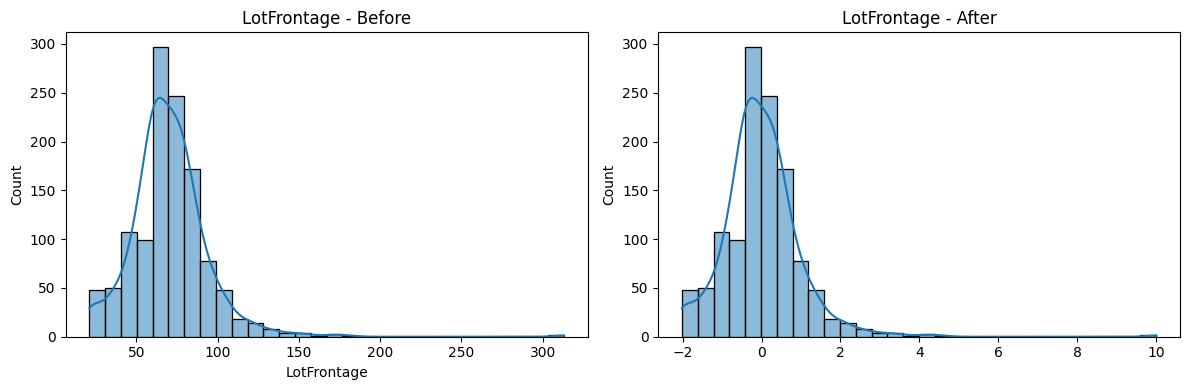

In [34]:
# Visual comparison
compare_distribution(df[col].dropna(), lot_scaled, col) # No change in shape, just rescaled to mean=0 and std=1

**MinMaxScaler — Summary (Pros / Cons / When to Use)**

**What it does:** Scales features to a fixed range, usually [0, 1], using the formula: $x' = (x - x_{min}) / (x_{max} - x_{min})$. The scaler stores per-feature `min_` and `scale_` to perform `transform` and `inverse_transform`.

**Key statistics concept:** min, max and range (max - min) determine scaling; the transform is linear and preserves the shape and distribution (no centering). Because scaling depends on observed min/max, it is sensitive to sample extremes (outliers) and to distribution shifts between training and test.

Let’s break down both of these concepts. They are the two biggest pitfalls of using `MinMaxScaler`.

### 1. "Sensitive to Sample Extremes (Outliers)"

Because `MinMaxScaler` relies **entirely** on the single absolute minimum ($X_{min}$) and maximum ($X_{max}$) values in your dataset to set the boundaries, a single massive outlier will ruin the scaling for all the normal data points.

#### The Visual Example:

Imagine you have a feature representing employee salaries.

- 99 employees earn between **$40,000** and **$100,000**.
- 1 CEO earns **$10,000,000** (the outlier).

When you apply `MinMaxScaler`:

- $X_{min} = 40,000$ becomes `0`.
- $X_{max} = 10,000,000$ becomes `1`.

Because the CEO's salary is so astronomical, the range ($X_{max} - X_{min}$) is massive. When you scale the other 99 normal employees, **all of their salaries will get squished into a tiny fraction between roughly `0` and `0.006`.** The algorithm loses all the granular variation between the normal employees' salaries because they’ve all been compressed into a tiny clump just to accommodate that one CEO.

### 2. "Sensitive to Distribution Shifts Between Training and Test"

In machine learning, you fit your scaler *only* on the training data, and then use that same scaler to transform the test data. This ensures no data leakage.

A **distribution shift** means the minimum and maximum values in your real-world test data (or future production data) turn out to be different than what the scaler saw during training. This causes two main problems:

#### Problem A: Out-of-Bounds Values

If your training data ranges from 10 to 50, `MinMaxScaler` learns that 10 is `0` and 50 is `1`. If your test data suddenly contains the number **60**, the formula will output **`1.25`**. If your machine learning model strictly expects inputs between `0` and `1` (like a neural network with specific activation functions), this out-of-bounds number can break its predictions.

#### Problem B: Incorrect Relative Scaling

If the test data has a completely different range, the "meaning" of the scaled numbers changes.

- **Training Data Range:** 0 to 100. A value of **50** scales to `0.5` (exactly the midpoint).
- **Test Data Range:** 50 to 1,000.

If the model sees a `0.5` in the test data, it thinks it's looking at a "midpoint" value. But because of the distribution shift, the actual numbers are completely different. The model's learned patterns no longer align with the reality of the new data.

### Summary

> - **Outlier Sensitivity:** One crazy high or low number squishes all your good data into a tiny, useless cluster.
> - **Distribution Shift Sensitivity:** If the future data has smaller minimums or larger maximums than your past data, your scaled values will spill outside the `[0, 1]` boundaries and confuse your model.
>
>

The short answer is **no, `MinMaxScaler` does not change the shape of your data's underlying distribution.** If your data is skewed, bimodal, or normally distributed before scaling, it will remain skewed, bimodal, or normally distributed after scaling. `MinMaxScaler` is a **linear transformation**, meaning it preserves the relative distances between all data points.

Here is a breakdown of how it works and what it actually changes.

### What It Actually Does

`MinMaxScaler` shifts and rescales your data so that all values fit into a specified range—typically between 0 and 1. The formula used for each feature is:

$$
X_{scaled} = \frac{X - X_{min}}{X_{max} - X_{min}}
$$

Think of it like **zooming in or out on a photograph, or resizing a shape bounding box**. If you resize a picture of a circle, it doesn't become a square; it just becomes a smaller or larger circle.

### What Changes vs. What Stays the Same

| What Changes 🔄 | What Stays the Same 🛑 |
| --- | --- |
| **The Scale/Range:** The data is compressed or expanded to fit strictly between your new minimum (e.g., 0) and maximum (e.g., 1). | **The Relative Distances:** The spacing between individual data points relative to one another remains identical. |
| **The Mean and Variance:** Because the actual numbers change, the average (mean) and how spread out they are (variance) will change. | **The Shape (Skewness/Kurtosis):** If you plot a histogram of the data before and after, the peaks, valleys, and tails will look exactly the same. |
| **Outliers:** Outliers are still present, but they are now crammed into the `[0, 1]` boundary, which forces the "normal" data points into a very tight, squished cluster. | **The Rank Order:** The smallest number remains the smallest, the largest remains the largest, and the order of all points in between is preserved. |

### When does a scaler *actually* change the distribution?

If your goal is to genuinely change the distribution shape—for instance, converting a highly skewed distribution into a normal (Gaussian) distribution—you need a **non-linear transformation**.

Standard scalers won't do this, but methods like **QuantileTransformer** or **PowerTransformer** (such as Box-Cox or Yeo-Johnson) will actively bend and reshape the data to force it into a normal distribution.

**Pros:**
- Produces features with a known bounded range (helpful for algorithms expecting inputs in [0,1]).
- Preserves the original distribution shape (no distortion beyond linear rescaling).
- Useful with algorithms that use bounded activations (e.g., some neural nets) or where relative proportion to a fixed range matters.
- `inverse_transform` can recover original units (except when clipping is applied).

**Cons:**
- Highly sensitive to outliers: an extreme value sets `min_`/`max_` and compresses the bulk of the data into a small interval.
- Not robust to distribution shifts: new test values outside training min/max will be mapped outside [0,1] (or clipped if configured), causing potential model issues.
- Because it preserves shape, it does not reduce skew or make distributions symmetric — combine with power transforms if needed.

**When to use:**
- When you need bounded inputs (0–1) for models or data pipelines (image pixel ranges, certain NN layers).
- When preserving the relative spacing and original distribution shape is desired (no nonlinear distortion).
- When features already have similar ranges or outliers are handled/removed.

**When to avoid / alternatives:**
- If outliers are present → prefer `RobustScaler` or handle outliers first.
- If you want unit variance/zero mean → use `StandardScaler` (or `PowerTransformer` + `StandardScaler`).
- If you need to preserve sparsity → `MinMaxScaler` can be used but be careful; `MaxAbsScaler` preserves zero entries and scales by max absolute value without shifting.

**Practical tips:**
- Always `fit` scalers on training data only and apply to validation/test to avoid leakage (use `Pipeline`).
- Consider `clip=True` if you want to force out-of-range test values back into the training range (beware information loss).
- Re-tune hyperparameters after scaling because scale affects optimizer behavior and regularization strength.

**Interview-ready one-liner:**
“MinMaxScaler linearly rescales features to a fixed range — great when bounded inputs are needed, but avoid it or pre-handle outliers because it’s sensitive to extremes.”

In [35]:
# ---------------------------------------------------
# 2. MinMax Scaling (bounded features: OverallQual [1-10])
# Formula: x' = (x - min) / (max - min)
# ---------------------------------------------------

col = "LotFrontage"
# Extract column as 2D array for sklearn
col_values = df[[col]]
# Create the MinMax scaler
scaler = MinMaxScaler()
# Fit to data and transform
minmax_scaled_array = scaler.fit_transform(col_values)
# Convert to Series for inspection
minmax_scaled = pd.Series(minmax_scaled_array.flatten())

print("Before:", summary_stats(df[col].dropna()))
print("After:", summary_stats(minmax_scaled))

Before: {'mean': np.float64(70.04995836802665), 'std': np.float64(24.284751774483208), 'skewness': np.float64(2.1635691423248837)}
After: {'mean': np.float64(0.1679793094795433), 'std': np.float64(0.0831669581317918), 'skewness': np.float64(2.1635691423248846)}


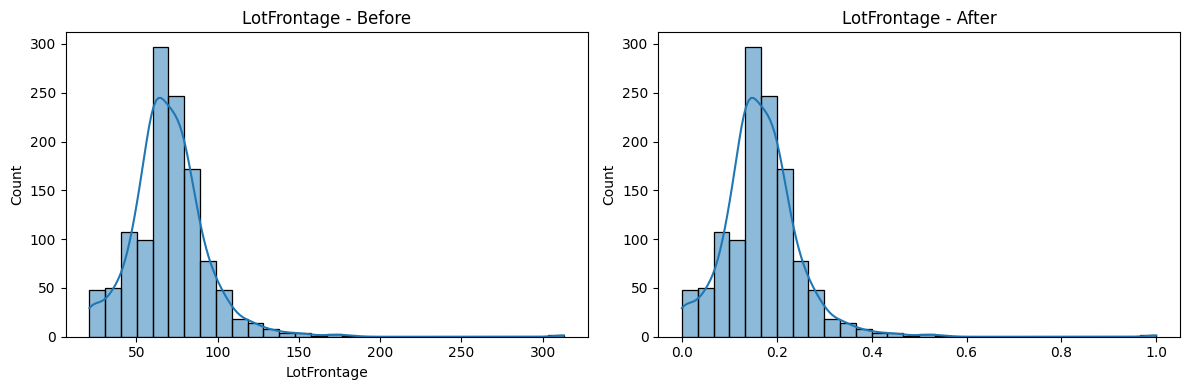

In [36]:
compare_distribution(df[col].dropna(), minmax_scaled, col) # No change in shape, just rescaled to [0, 1]

**Robust Scaling** (or Robust Standardization) is a powerful feature scaling technique used in machine learning to prepare numerical data for algorithms. Unlike Standard Scaling, which relies on the mean and standard deviation, Robust Scaling uses statistics that are not easily influenced by outliers.

Here is a comprehensive summary of how it works, its pros and cons, and when you should deploy it.

## 🧠 The Core Statistical Concept

To understand Robust Scaling, we have to look at the math behind it. It scales features using the **Median** and the **Interquartile Range (IQR)**.

The formula for Robust Scaling a feature $x$ is:

$$
x_{scaled} = \frac{x - \text{median}(x)}{\text{IQR}(x)}
$$

Where the Interquartile Range is calculated as:

$$
\text{IQR} = Q_3 - Q_1
$$

### Key Statistical Terms:

- **Median ($Q_2$ / 50th Percentile):** The middle value of the dataset. Unlike the mean, which can be dragged heavily by a single massive outlier, the median remains anchored in the actual center of the data distribution.
- **Interquartile Range ($\text{IQR}$):** The distance between the 25th percentile ($Q_1$) and the 75th percentile ($Q_3$). It captures the middle 50% of your data. Because it ignores the upper and lower 25% of the data, extreme outliers have zero impact on the IQR.
-

## ➕ Pros & ➖ Cons

### Pros

- **Outlier Immunity:** Because it uses the median and IQR, the scaling process itself isn't warped by extreme anomalies. Your normal data points won't get squished into a tiny, indistinguishable cluster.
- **Preserves Variance:** It maintains the relative distances and variance between your normal data points better than Standard Scaler when outliers are present.
- **Better Model Performance:** Algorithms sensitive to feature scale (like SVMs, KNN, and Linear Regression) perform significantly better on noisy datasets.

### Cons

- **Outliers Are Still Present:** Robust Scaling *ignores* outliers during the calculation, but it does **not** remove or clip them. The outliers will still exist in the final scaled data, just pulled to a relative scale.
- **Linear Relationships Only:** It performs a linear transformation. If your data has complex non-linear relationships, scaling alone won't fix it.
- **Not Ideal for Bound Output:** Unlike MinMax Scaling (which binds data strictly between 0 and 1), Robust Scaling results in an open-ended range.

## 🎯 When to Use Robust Scaling

| Scenario | Use Robust Scaling? | Alternative |
| --- | --- | --- |
| Data contains **significant outliers** that you cannot legally or safely remove (e.g., fraud detection, rare medical anomalies). | **Yes** ✅ | None |
| Data is **normally distributed** (Gaussian) with no major outliers. | **No** ❌ | **Standard Scaler** (Mean/StdDev) |
| You are using **Neural Networks** or algorithms that strictly require a bounded input range (like 0 to 1). | **No** ❌ | **MinMax Scaler** |
| You are using **Tree-based models** (Random Forest, XGBoost). | **Optional** 🤷 (Trees are scale-invariant, so scaling rarely changes performance). | None |

### Summary Checklist for Implementation:

> Use **Robust Scaler** when your dataset is messy, full of unpredictable spikes or measurement errors, and you need a scaling method that won't lose its mind when an outlier appears.
>
>

In [37]:
# ---------------------------------------------------
# 3. Robust Scaling (outliers present: GrLivArea)
# Formula: x' = (x - median) / IQR
# RobustScaler uses median and IQR so it's less sensitive to outliers.
# ---------------------------------------------------

col = "LotFrontage"
# Extract as 2D array
col_values = df[[col]]
# Create a RobustScaler instance
scaler = RobustScaler()
# Fit and transform the data; returns numpy array
robust_scaled_array = scaler.fit_transform(col_values)
robust_scaled = pd.Series(robust_scaled_array.flatten())

print("Before:", summary_stats(df[col].dropna()))
print("After:", summary_stats(robust_scaled))

Before: {'mean': np.float64(70.04995836802665), 'std': np.float64(24.284751774483208), 'skewness': np.float64(2.1635691423248837)}
After: {'mean': np.float64(0.04999801752507831), 'std': np.float64(1.156416751165867), 'skewness': np.float64(2.163569142324884)}


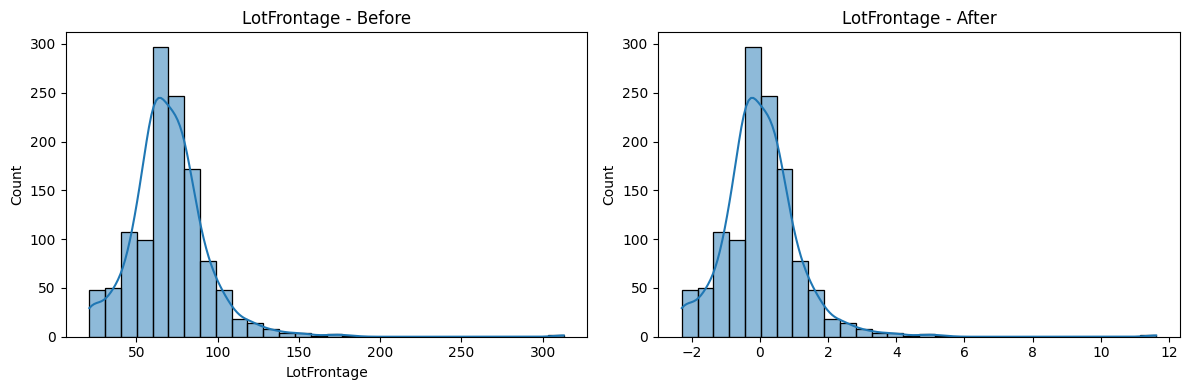

In [38]:
compare_distribution(df[col].dropna(), robust_scaled, col) # No change in shape, just rescaled to median=0 and IQR=1

In [39]:
# Robust scaling applied to `GrLivArea` (example for a feature with outliers).
col = "GrLivArea"
col_values = df[[col]]
scaler = RobustScaler()
grliv_scaled_array = scaler.fit_transform(col_values)
grliv_scaled = pd.Series(grliv_scaled_array.flatten())

print("Before:", summary_stats(df[col].dropna()))
print("After:", summary_stats(grliv_scaled))

Before: {'mean': np.float64(1515.463698630137), 'std': np.float64(525.4803834232025), 'skewness': np.float64(1.3665603560164552)}
After: {'mean': np.float64(0.0795113149944179), 'std': np.float64(0.8118661775561259), 'skewness': np.float64(1.3665603560164554)}


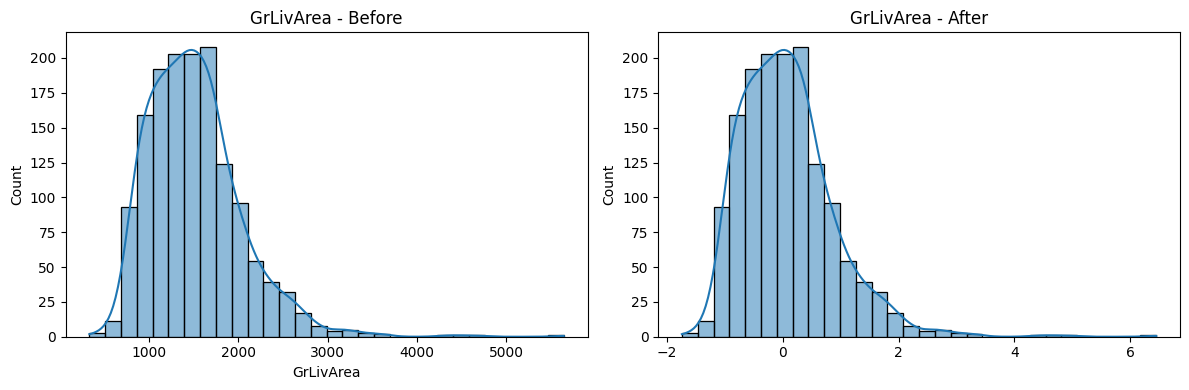

In [40]:
compare_distribution(df[col].dropna(), grliv_scaled, col)

In [41]:
# Robust scaling applied to `SalePrice` to illustrate effect on skew/outliers.
col = "SalePrice"
col_values = df[[col]]
scaler = RobustScaler()
saleprice_scaled_array = scaler.fit_transform(col_values)
saleprice_scaled = pd.Series(saleprice_scaled_array.flatten())

print("Before:", summary_stats(df[col].dropna()))
print("After:", summary_stats(saleprice_scaled))


Before: {'mean': np.float64(180921.19589041095), 'std': np.float64(79442.50288288662), 'skewness': np.float64(1.8828757597682129)}
After: {'mean': np.float64(0.21328409271539375), 'std': np.float64(0.9454626942325095), 'skewness': np.float64(1.8828757597682129)}


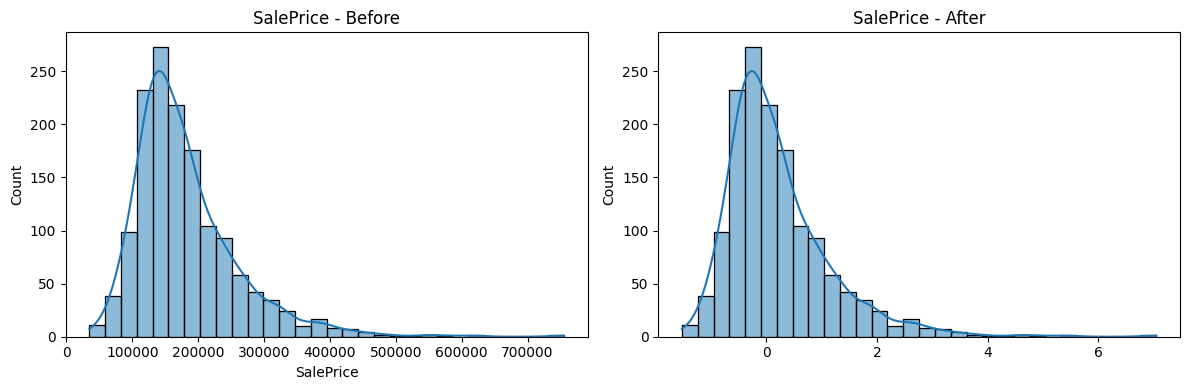

In [42]:
compare_distribution(df[col].dropna(), saleprice_scaled, col)

**Log Transformation** is a data transformation technique used to linearize relationships, stabilize variance, and convert highly skewed distributions into something closer to a normal (Gaussian) distribution.

Unlike traditional scaling methods (like Standard or MinMax scaling) that simply shift and compress data linearly, a log transformation **structurally changes the shape of the data distribution**.

## 🧠 The Core Statistical Concepts

Log transformation relies on a few fundamental mathematical and statistical principles:

### 1. Handling Skewness (Right-Skewed Data)

Many real-world datasets exhibit a **right skew** (positive skew), where a majority of the data points are clustered at lower values, but a long "tail" of very large values extends to the right. Applying the natural logarithm ($\ln(x)$) or base-10 logarithm ($\log_{10}(x)$) compresses the long tail **because it shrinks larger values much more drastically than smaller values**.

### 2. Heteroscedasticity vs. Homoscedasticity

- **Heteroscedasticity** occurs when the spread (variance) of your data changes across the range of data of an independent variable (e.g., as income increases, the variance in spending increases).
- Many machine learning and statistical models assume **Homoscedasticity** (constant variance). A log transformation "stabilizes" this variance, making the spread uniform across the dataset.

- To understand how a log transformation fixes **heteroscedasticity** (unequal variance) and turns it into **homoscedasticity** (constant variance), it helps to look at a real-world example: **Predicting House Prices based on Square Footage.**

## 🏠 The Real-World Scenario: House Prices

Imagine you are building a linear regression model to predict a house's price based on its size (square footage).

### The Problem: Heteroscedasticity (The "Cone" Shape)

In the real world, as houses get larger, their price variance explodes:

- **Small houses (1,000 sq ft):** The price might range from $150,000 to $200,000. The spread (variance) is quite small—only **$50,000**.
- **Mansion-sized houses (10,000 sq ft):** The price could range from $2,000,000 to $5,000,000 depending on luxury finishes, location, or history. The spread is massive—**$3,000,000**.

If you plot this unscaled data on a graph, the data points scatter tight and close together on the left (small houses) but fan out wide into a **cone or megaphone shape** on the right (large houses).

### Why this breaks your model:

Linear regression tries to draw a single straight line through the data. Because the large houses have such massive absolute differences in price, the model's math will obsess over trying to minimize the errors for those giant mansions. In doing so, it completely ignores the small houses, ruining the model's accuracy for the majority of everyday homes.

## 🧮 The Fix: How Log Transformation "Stabilizes" the Spread

When you apply a log transformation to the price variable, you change the model's perspective from **absolute dollar differences** to **percentage (multiplicative) differences**.

Let’s look at what the logarithm does to those variances:

- **Small houses:** A change from $150,000 to $200,000 is a **33% increase**. $$ \log_{10}(200,000) - \log_{10}(150,000) \approx 5.30 - 5.17 = \mathbf{0.13} $$
- **Mansions:** A change from $2,000,000 to $2,660,000 is *also* a **33% increase**. $$ \log_{10}(2,660,000) - \log_{10}(2,000,000) \approx 6.42 - 6.30 = \mathbf{0.13} $$

Notice what just happened? In raw dollars, the mansion spread ($660,000) was vastly larger than the small house spread ($50,000). But in **log space**, both spreads are exactly **0.13**.

## 🎯 The Result: Homoscedasticity

By taking the log, you pull the massive, scattered prices of the mansions down to the same relative scale as the smaller houses.

If you replot the log-transformed data, that wild "cone" shape disappears. Instead, the data points form a **uniform, parallel band** along the regression line. The spread of the data is now constant from left to right.

### Impact on the Machine Learning Model:

1. **Equal Treatment:** The model now treats a 10% error on a cheap house with the exact same weight as a 10% error on a mansion.
2. **Valid Statistics:** The mathematical assumptions of Linear Regression are satisfied. Your model's confidence intervals, standard errors, and $p$-values become mathematically sound and trustworthy.
3. **Better Lines of Best Fit:** The resulting line isn't violently yanked around by a few hyper-expensive properties, leading to better generalizations across all house sizes.

### 3. Multiplicative to Additive Relationships

If your data has a multiplicative relationship (e.g., a compound growth rate where something increases by 10% each year), taking the logarithm converts that exponential growth into a straight, linear trend:

$$
\log(A \times B) = \log(A) + \log(B)
$$

## ➕ Pros & ➖ Cons

### Pros

- **Normalizes Residuals:** It helps satisfy the core assumptions of linear models (like Linear Regression), leading to more valid $p$-values and confidence intervals.
- **Reduces Outlier Impact:** Extreme values are pulled dramatically closer to the center of the distribution, neutralizing their ability to single-handedly skew a model.
- **Reveals Linear Trends:** It uncovers hidden linear relationships in exponential or power-law data.

### Cons

- **Cannot Handle Zero or Negative Values:** The logarithm of zero ($\log(0)$) is undefined ($-\infty$), and negative numbers yield complex numbers. If your data contains zeros or negatives, you must apply a shift, such as the **Log1p** transformation: $\log(x + 1)$.
- **Loses Interpretability:** Once transformed, the features are no longer in their original units (e.g., instead of "Dollars," you are looking at "Log of Dollars"). You have to exponentiate the model's outputs to interpret them in the real world.
- **Can Ruin Already-Normal Data:** If applied to data that is already uniformly or normally distributed, it can introduce a heavy *left* skew and degrade model performance.

## 🎯 When to Use Log Transformation

| Scenario | Use Log Transformation? | Alternative |
| --- | --- | --- |
| Your data is **highly right-skewed** (e.g., income, house prices, web traffic count, population size). | **Yes** ✅ | Box-Cox or Yeo-Johnson |
| The variance of your errors increases as your target variable increases (**Heteroscedasticity**). | **Yes** ✅ | Weighted Least Squares |
| Your dataset contains **zeros or negative numbers**. | **No** ❌ (Unless shifted) | **Log1p** ($\log(x+1)$) or **Yeo-Johnson** |
| Your data is already **normally distributed** or symmetric. | **No** ❌ | **Standard Scaler** |

### Summary Checklist for Implementation:

> Use **Log Transformation** when you want to change the *distribution shape* of a feature, not just its range. If your data spans several orders of magnitude (e.g., 10, 100, 10,000, 1,000,000), a log transform will bring them onto a manageable, linear scale.
>
>

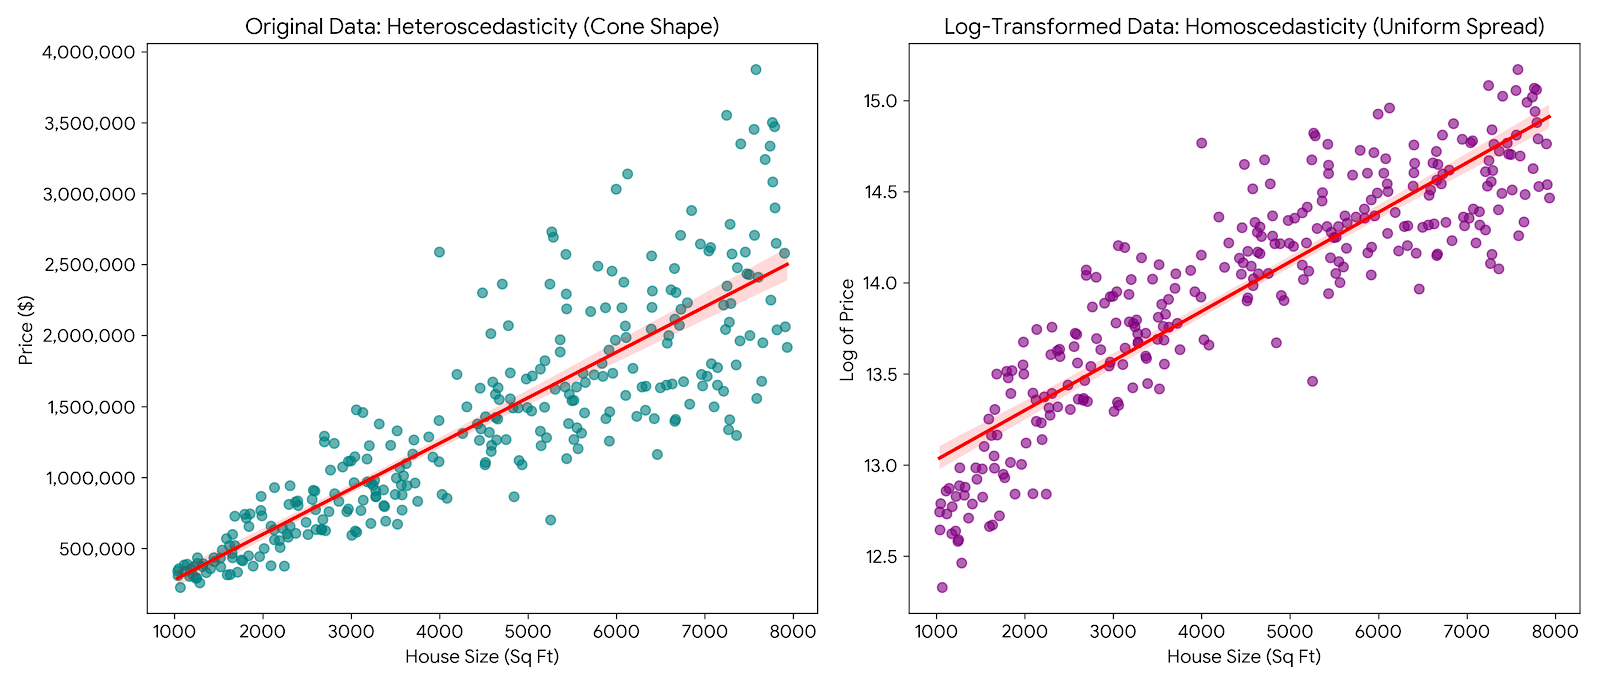

In [43]:
import numpy as np

In [44]:
# ---------------------------------------------------
# 4. Log Transformation (right-skewed: SalePrice)
# Formula: x' = log( x + 1 ) -> use log1p to handle zeros safely
# ---------------------------------------------------

col = "SalePrice"
# Take the Series (1D) because numpy log operates elementwise on 1D/array-like
series = df[col]  # pandas Series
# Apply log1p: log(1 + x) which is stable for x=0 and small x
log_trans = np.log1p(series) #log transformation using numpy's log1p function, which computes log(1 + x) for each element in the series.

print("Before:", summary_stats(series.dropna()))
print("After:", summary_stats(log_trans.dropna()))

Before: {'mean': np.float64(180921.19589041095), 'std': np.float64(79442.50288288662), 'skewness': np.float64(1.8828757597682129)}
After: {'mean': np.float64(12.024057394918406), 'std': np.float64(0.3994492733225068), 'skewness': np.float64(0.12134661989685333)}


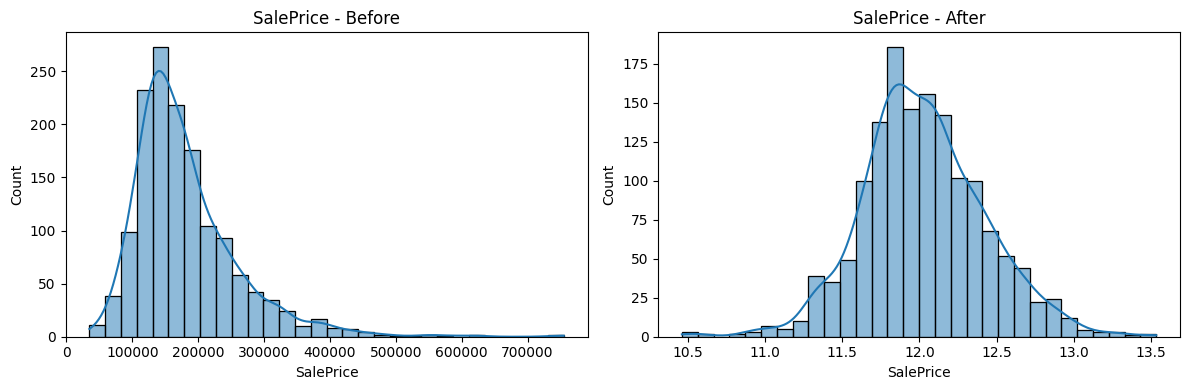

In [45]:
compare_distribution(series.dropna(), log_trans.dropna(), col) # log transformation changes the shape of the distribution, often making it more symmetric and less skewed, especially for right-skewed data like SalePrice.

**Box-Cox Transformation** is a configurable variance-stabilizing transformation that automatically finds the optimal power transformation to normalize skewed data.

While a log transformation is a "one-size-fits-all" tool, Box-Cox tests a spectrum of power transformations to dynamically reshape your data distribution into a normal (Gaussian) curve.

## ❓ What is it? (The Mathematical Core)

The Box-Cox transformation relies on a single parameter, **Lambda ($\lambda$)**. It searches for the exact value of $\lambda$ (usually between $-5$ and $5$) that maximizes the log-likelihood that the transformed data is normally distributed.

The mathematical formula applied to a feature $x$ is:

$$
x^{(\lambda)} = \begin{cases} \frac{x^\lambda - 1}{\lambda} & \text{if } \lambda \neq 0 \\ \ln(x) & \text{if } \lambda = 0 \end{cases}
$$

### How $\lambda$ Adapts to Different Shapes:

Instead of choosing blindly, the Box-Cox algorithm calculates the best $\lambda$ for your specific data structure. It mimics several famous transformations based on the resulting value:

- **$\lambda = 1$:** No transformation (the data is already linear/normal).
- **$\lambda = 0.5$:** Square root transformation ($\sqrt{x}$).
- **$\lambda = 0$:** Natural log transformation ($\ln(x)$).
- **$\lambda = -1$:** Reciprocal transformation ($1/x$).

## 🧠 Important Statistical Concepts

### 1. Maximum Likelihood Estimation (MLE)

Box-Cox doesn't guess the value of $\lambda$. It uses a statistical method called **Maximum Likelihood Estimation**. The algorithm treats $\lambda$ as an unknown parameter and runs an optimization routine to find the precise value that yields the highest probability of creating a perfect, bell-shaped normal curve.

### 2. Normality Assumptions

Many classic statistical models (like ANOVA, t-tests, and Linear Regression) strictly assume that the underlying data or its residuals are normally distributed. Box-Cox is specifically engineered to satisfy this assumption when human data collection yields skewed results.

## ➕ Pros & ➖ Cons

### Pros

- **Highly Flexible:** It doesn't lock you into one specific transformation. It customizes itself to the unique skewness of your dataset.
- **Reduces Heteroscedasticity:** Like the log transform, it effectively stabilizes variance across the target vector.
- **Optimizes Model Assumptions:** It handles data that is both gently skewed and heavily skewed by sweeping across fraction-based powers.

### Cons

- **Strict Positive Constraint ($x \gt 0$):** The standard Box-Cox formulation **cannot handle zero or negative values**. If your data has a single $0$ or negative number, the math breaks.
- **Completely Destroys Interpretability:** Because $\lambda$ can be a complex decimal (e.g., $\lambda = 0.273$), the resulting units have no real-world meaning, making it incredibly difficult to explain feature weights to stakeholders.
- **Computationally Heavy:** Finding the optimal $\lambda$ via MLE requires iterative scanning, which adds processing overhead on massive datasets compared to a simple log or square root function.

## 🎯 When to Use Box-Cox

| Scenario | Use Box-Cox? | Alternative |
| --- | --- | --- |
| Your data is continuously **positive ($x \gt 0$)** and skewed, and a simple log transform didn't fully normalize it. | **Yes** ✅ | None |
| You are preparing data for **parametric models** (Linear Regression, ANOVA) that require strict Gaussian distributions. | **Yes** ✅ | Yeo-Johnson |
| Your data contains **zeros or negative numbers**. | **No** ❌ | **Yeo-Johnson Transformation** (a modified version of Box-Cox built for negatives) |
| You need to explain the **exact physical meaning** of your features to non-technical business leaders. | **No** ❌ | **Standard Scaler** or standard **Log Transform** |

### Summary Checklist for Implementation:

> Use **Box-Cox** when your data is strictly positive and you want an automated, statistically optimized way to enforce a normal distribution, provided that losing the literal real-world meaning of your units isn't a dealbreaker.
>
>

In [46]:
# ---------------------------------------------------
# 5. Box-Cox / Yeo-Johnson (can handle different skew types)
# - Box-Cox requires strictly positive data.
# - Yeo-Johnson can handle zero and negative values.
# ---------------------------------------------------

col = "LotArea"
# Prepare data as 2D array for sklearn's PowerTransformer
col_values = df[[col]]
# Box-Cox: only use if data > 0. Add a check or use yeo-johnson if not positive.
pt_boxcox = PowerTransformer(method="box-cox")
# Fit and transform (will raise if data contains non-positive values)
lotarea_boxcox_array = pt_boxcox.fit_transform(col_values)
lotarea_boxcox = pd.Series(lotarea_boxcox_array.flatten())

print("Before:", summary_stats(df[col].dropna()))
print("After (Box-Cox):", summary_stats(lotarea_boxcox))

Before: {'mean': np.float64(10516.828082191782), 'std': np.float64(9981.26493237915), 'skewness': np.float64(12.207687851233496)}
After (Box-Cox): {'mean': np.float64(5.560240243876127e-16), 'std': np.float64(1.0003426417780867), 'skewness': np.float64(0.026687011208083273)}


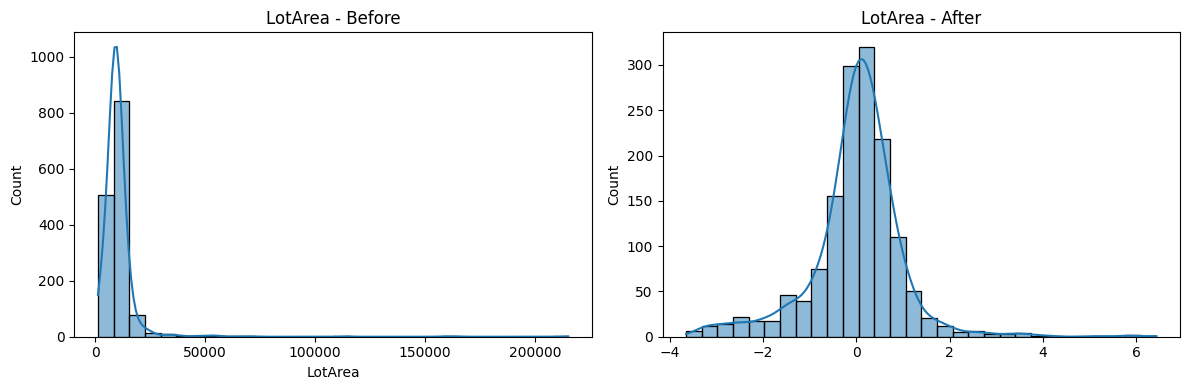

In [47]:
compare_distribution(df[col].dropna(), lotarea_boxcox, col)

- **Yeo-Johnson Transformation** is a modern variance-stabilizing power transformation designed to normalize data and stabilize variance. It was introduced by Inbeom Yeo and Richard Johnson in 2000 as a direct extension of the Box-Cox transformation to overcome its biggest limitation: the inability to handle zero and negative values.

## ❓ What is it? (The Mathematical Core)

Like Box-Cox, the Yeo-Johnson transformation uses a tuning parameter, **Lambda ($\lambda$)**, to find the optimal power transformation using **Maximum Likelihood Estimation (MLE)**. However, its mathematical formulation alters based on whether a data point is positive or negative.

The formula applied to a feature $x$ is:

$$
x^{(\lambda)} = \begin{cases} \frac{(x + 1)^\lambda - 1}{\lambda} & \text{if } \lambda \neq 0, x \geq 0 \\ \ln(x + 1) & \text{if } \lambda = 0, x \geq 0 \\ -\frac{(-x + 1)^{2 - \lambda} - 1}{2 - \lambda} & \text{if } \lambda \neq 2, x \lt 0 \\ -\ln(-x + 1) & \text{if } \lambda = 2, x \lt 0 \end{cases}
$$

By modifying the functions for negative values, it ensures that the transformation remains smooth, continuous, and monotonic across the entire real number line.

## 🧠 Important Statistical Concepts

### 1. Zero and Negative Value Continuity

In statistics, applying a power transform to negative numbers traditionally causes mathematical errors (e.g., you cannot take the square root or logarithm of a negative number). The Yeo-Johnson transformation solves this by applying a inverse-symmetric power function to negative values. This preserves the ordering of the data while successfully stabilizing the variance.

### 2. Monotonicity

A critical requirement for any feature scaling technique is that it must be **monotonic**. This means that if a raw data point $A$ is greater than $B$, then after the transformation, $A_{scaled}$ must still be greater than $B_{scaled}$. Yeo-Johnson is mathematically engineered to maintain this property across both positive and negative spectrums simultaneously.

## ➕ Pros & ➖ Cons

### Pros

- **No Value Restrictions:** It seamlessly handles positive numbers, strictly zero, and negative numbers all at once.
- **Highly Adaptable:** It automatically determines whether your data needs a log-like shift, a square root, or an inversion based on the calculated $\lambda$.
- **Enforces Gaussian Behavior:** It is incredibly effective at turning highly skewed, noisy distributions (with mixed signs) into clean, bell-shaped normal distributions.

### Cons

- **Complex Interpretation:** Because the math applies different transformations to positive and negative numbers under a decimal $\lambda$, the resulting units have no real-world physical meaning.
- **Computationally Intensive:** The optimization routine to pinpoint the best $\lambda$ across thousands or millions of rows takes more processing time than linear scaling methods.
- **Over-transformation Risk:** If a feature does not actually benefit from a power transformation, forcing a Yeo-Johnson transform can unnecessarily distort the data structure.

## 🎯 When to Use Yeo-Johnson

| Scenario | Use Yeo-Johnson? | Alternative |
| --- | --- | --- |
| Your data contains **zeros or negative numbers** and is heavily skewed, but you need it to be normally distributed. | **Yes** ✅ | None |
| Your data is strictly **positive ($x \gt 0$)** and skewed. | **Optional** 🤷 (It works, but Box-Cox is the standard choice here) | **Box-Cox** |
| You are training algorithms that assume normality (Linear Regression, Logistic Regression, LDA) on mixed-sign data. | **Yes** ✅ | Standard Scaler (if data isn't highly skewed) |
| You are using **Tree-based models** (Random Forest, Gradient Boosting) where distribution shape doesn't matter. | **No** ❌ | No scaling needed |

### Summary Checklist for Implementation:

> Use **Yeo-Johnson** as your ultimate "failsafe" power transform. When a dataset is highly skewed but you cannot use Box-Cox or standard Log transforms because of zero values or negative numbers, Yeo-Johnson is mathematically designed to handle it without breaking.
>
>

In [48]:
# Yeo-Johnson variant (safe for zero/negative values)
col = "LotArea"
col_values = df[[col]]
pt_yj = PowerTransformer(method="yeo-johnson")
lotarea_yj_array = pt_yj.fit_transform(col_values)
lotarea_yj = pd.Series(lotarea_yj_array.flatten())

print("Before:", summary_stats(df[col].dropna()))
print("After (Yeo-Johnson):", summary_stats(lotarea_yj))


Before: {'mean': np.float64(10516.828082191782), 'std': np.float64(9981.26493237915), 'skewness': np.float64(12.207687851233496)}
After (Yeo-Johnson): {'mean': np.float64(1.0816309796074127e-15), 'std': np.float64(1.0003426417780865), 'skewness': np.float64(0.026569113431681807)}


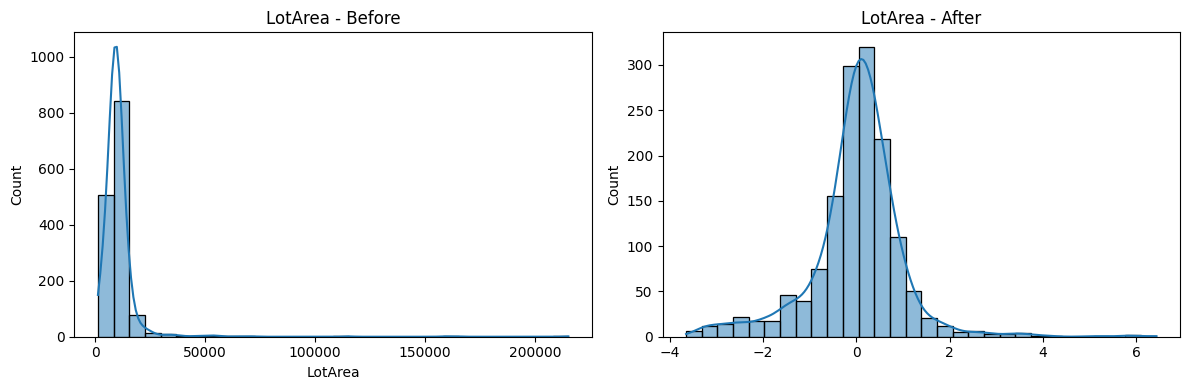

In [49]:
compare_distribution(df[col].dropna(), lotarea_yj, col)

In [50]:
# square-root transformation: useful for mild right skew.
# Use numpy's sqrt which handles arrays efficiently (avoid apply+lambda for speed).
df_applied = df.copy()
col = "LotFrontage"
# Create a copy of the column values and apply sqrt elementwise
df_applied[col] = np.sqrt(df_applied[col])


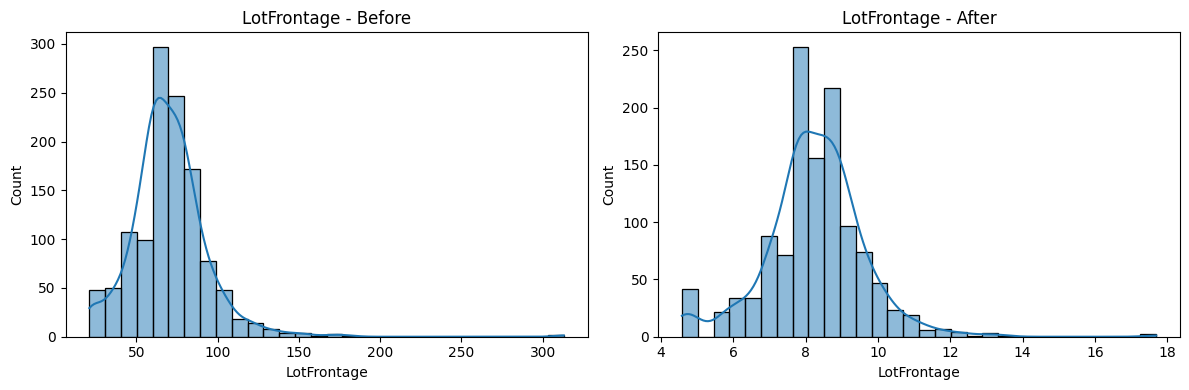

In [51]:
compare_distribution(df[col].dropna(), df_applied[col].dropna(), col)

In [52]:
# cube-root transformation: can handle both positive and negative values gracefully.
df_applied_cube = df.copy()
col = "LotFrontage"
# Use numpy's cbrt for elementwise cube-root
df_applied_cube[col] = np.cbrt(df_applied_cube[col])


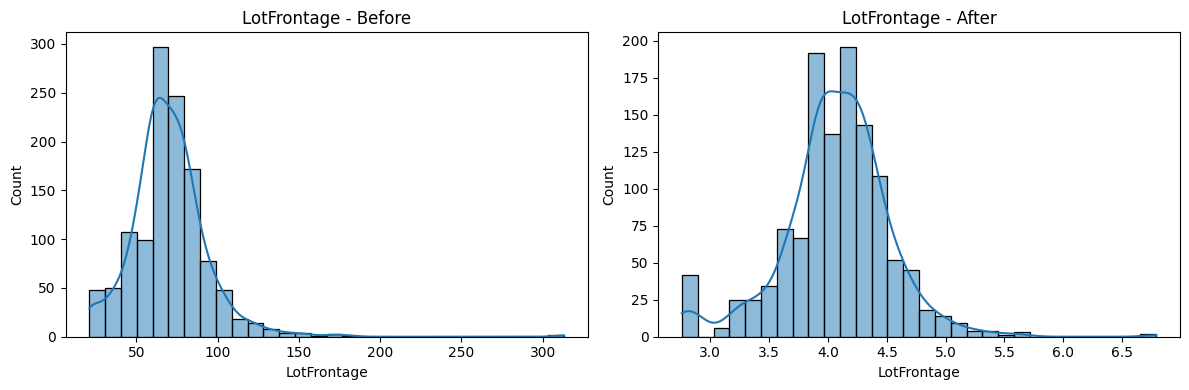

In [53]:
compare_distribution(df[col].dropna(), df_applied_cube[col].dropna(), col)